In [2]:
import pandas as pd
df = pd.read_csv("fear_greed_index.csv")
df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [3]:
df.shape

(2644, 4)

In [4]:
df.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

In [5]:
df.info

<bound method DataFrame.info of        timestamp  value classification        date
0     1517463000     30           Fear  2018-02-01
1     1517549400     15   Extreme Fear  2018-02-02
2     1517635800     40           Fear  2018-02-03
3     1517722200     24   Extreme Fear  2018-02-04
4     1517808600     11   Extreme Fear  2018-02-05
...          ...    ...            ...         ...
2639  1745818200     54        Neutral  2025-04-28
2640  1745904600     60          Greed  2025-04-29
2641  1745991000     56          Greed  2025-04-30
2642  1746077400     53        Neutral  2025-05-01
2643  1746163800     67          Greed  2025-05-02

[2644 rows x 4 columns]>

In [6]:
df.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [7]:
df.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['date']=pd.to_datetime(df['date'])

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   str           
 3   date            2644 non-null   datetime64[us]
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 82.8 KB


In [11]:
df['classification'].unique()

<StringArray>
['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed']
Length: 5, dtype: str

In [12]:
df['sentiment_score'] = df['classification'].map({
    'Extreme Fear': 0,
    'Fear' : 1,
    'Greed' : 2,
    'Extreme Greed': 3
})

In [13]:
df = df.sort_values(by="date")

In [14]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        2644 non-null   int64         
 1   value            2644 non-null   int64         
 2   classification   2644 non-null   str           
 3   date             2644 non-null   datetime64[us]
 4   sentiment_score  2248 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 103.4 KB


In [15]:
df['classification'].value_counts()

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

In [16]:
df['classification'] = df['classification'].str.strip()

In [17]:
df['sentiment_score']= df['classification'].map({
    'Extreme Fear':0,
    "Fear":1,
    "Neutral":2,
    "Greed":3,
    "Extreme Greed":4
})

In [19]:
df["sentiment_score"].isnull().sum()

np.int64(0)

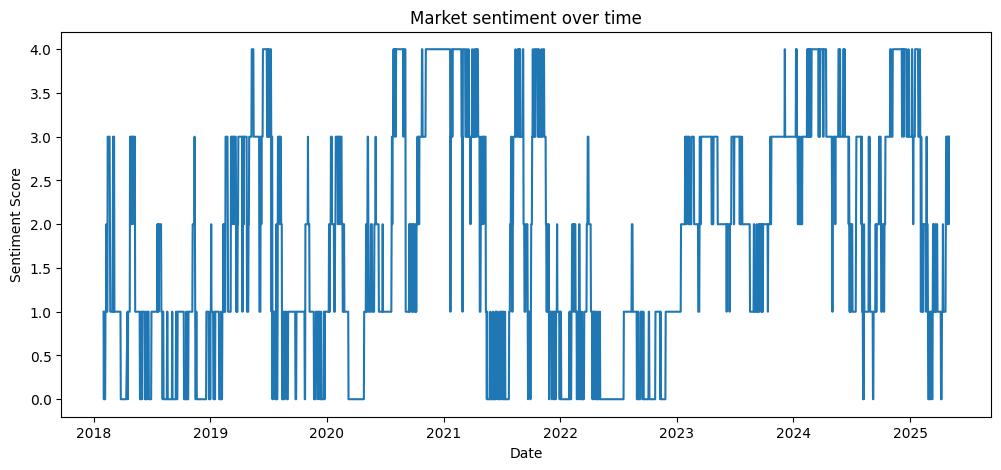

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df["date"], df["sentiment_score"])
plt.title("Market sentiment over time")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.show()

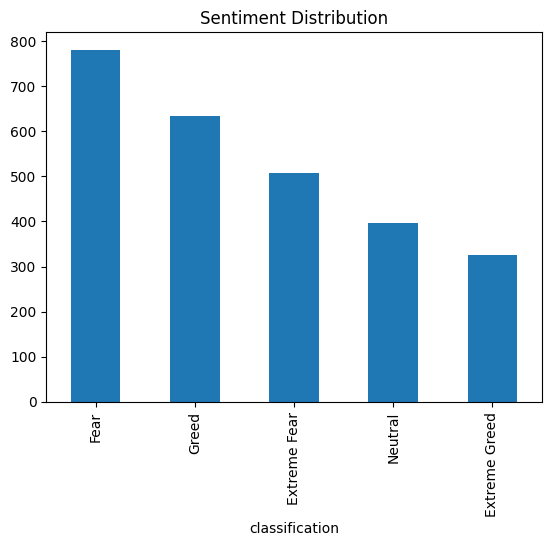

In [21]:
df['classification'].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.show()

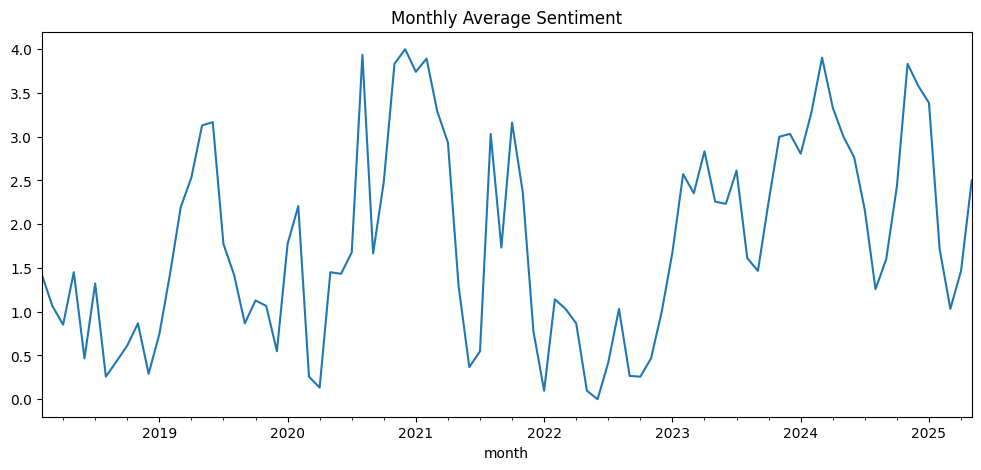

In [22]:
df["month"] = df['date'].dt.to_period("M")
monthly_sentiment = df.groupby("month")['sentiment_score'].mean()
monthly_sentiment.plot(figsize=(12,5))
plt.title("Monthly Average Sentiment")
plt.show()

In [23]:
df[df["classification"]== 'Extreme Fear']
df[df["classification"]== 'Extreme Greed']


,timestamp,value,classification,date,sentiment_score,month
461,1557552600,76,Extreme Greed,2019-05-11,4,2019-05
462,1557639000,75,Extreme Greed,2019-05-12,4,2019-05
463,1557725400,78,Extreme Greed,2019-05-13,4,2019-05
464,1557811800,78,Extreme Greed,2019-05-14,4,2019-05
465,1557898200,77,Extreme Greed,2019-05-15,4,2019-05
...,...,...,...,...,...,...
2543,1737523800,84,Extreme Greed,2025-01-22,4,2025-01
2544,1737610200,75,Extreme Greed,2025-01-23,4,2025-01
2545,1737696600,75,Extreme Greed,2025-01-24,4,2025-01
2546,1737783000,75,Extreme Greed,2025-01-25,4,2025-01


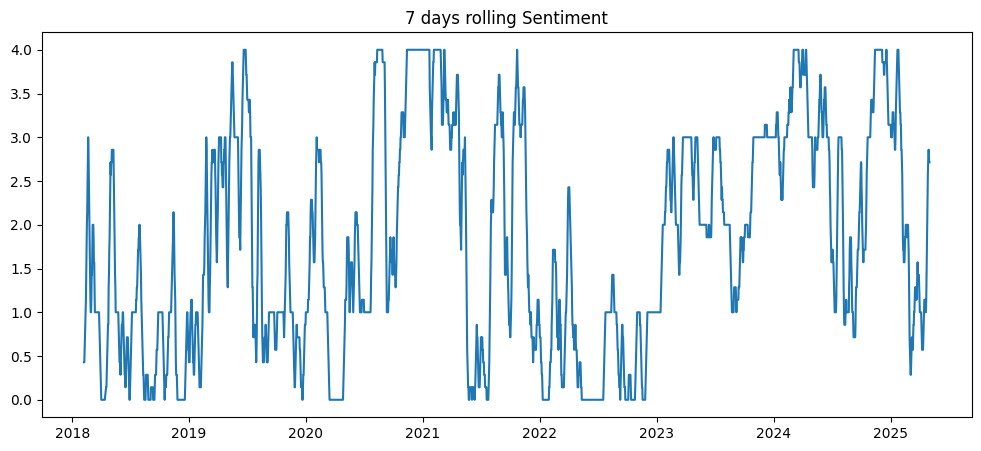

In [25]:
df['rolling_sentiment']=df['sentiment_score'].rolling(window=7).mean()
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['rolling_sentiment'])
plt.title("7 days rolling Sentiment")
plt.show()

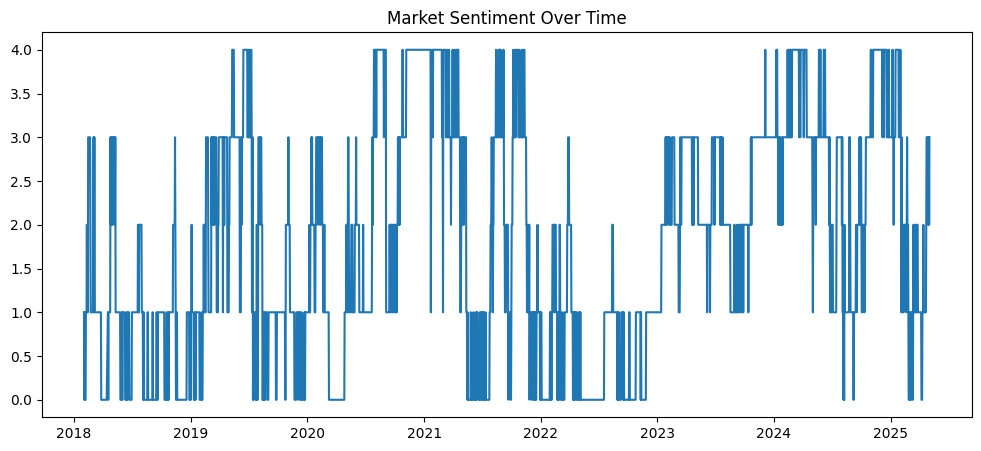

In [26]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['sentiment_score'])
plt.title("Market Sentiment Over Time")

plt.savefig("sentiment_trend.png")  
plt.show()

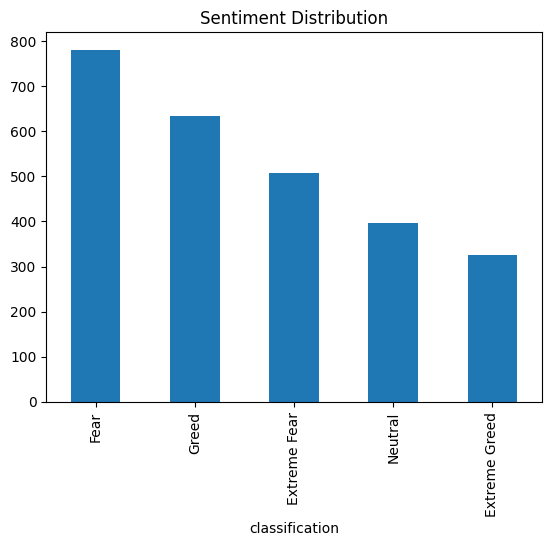

In [27]:
df['classification'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.savefig("sentiment_distribution.png")
plt.show()